# NB5 · Retention Strategy & ML Churn Scorer

**Goal**: Turn insights from NB2–4 into an *actionable* retention system.  
This notebook has two parts:

**Part A — Analytics**: Who should we target, and with what offer?  
We build a risk-vs-value matrix: high churn risk AND high monthly charges = top retention targets.

**Part B — Light ML**: A logistic regression churn scorer that assigns each customer a churn probability.  
This is deliberately simple — interpretable, deployable, and a good baseline before gradient boosting.

**Requires**: `telco_segmented.csv` produced by NB3.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, roc_auc_score,
                              RocCurveDisplay, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('telco_segmented.csv')
print(f'Loaded {df.shape[0]:,} rows')

Loaded 7,043 rows


## PART A · WHO TO TARGET

### 1 · Risk vs value matrix

We score every customer on two axes:
- **Churn risk proxy** — is contract M2M, tenure < 12, no security, no support? (sum of risk flags)
- **Value** — their `MonthlyCharges`

The top-right quadrant (high risk + high value) is the priority retention cohort.

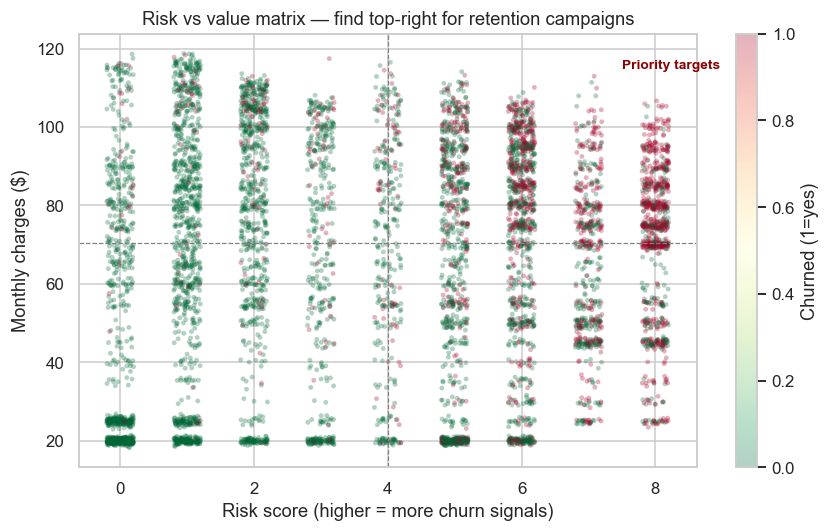

Priority targets: 2,034 customers
Their churn rate: 52.9%
Their total MRR at risk: $178,848/mo


In [2]:
# Build a simple risk score from known churn drivers
df['risk_score'] = (
    (df['Contract'] == 'Month-to-month').astype(int) * 3 +
    (df['tenure'] <= 12).astype(int) * 2 +
    (df['OnlineSecurity'] == 'No').astype(int) +
    (df['TechSupport'] == 'No').astype(int) +
    (df['PaperlessBilling'] == 'Yes').astype(int)
)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    df['risk_score'] + np.random.uniform(-0.2, 0.2, len(df)),  # jitter for readability
    df['MonthlyCharges'],
    c=df['Churn_flag'], cmap='RdYlGn_r', alpha=0.3, s=10, edgecolors='none'
)
plt.colorbar(sc, ax=ax, label='Churned (1=yes)')

# Quadrant lines at median
ax.axvline(df['risk_score'].median(), color='gray', linewidth=0.8, linestyle='--')
ax.axhline(df['MonthlyCharges'].median(), color='gray', linewidth=0.8, linestyle='--')
ax.text(7.5, 115, 'Priority targets', fontsize=9, color='darkred', weight='bold')

ax.set_xlabel('Risk score (higher = more churn signals)')
ax.set_ylabel('Monthly charges ($)')
ax.set_title('Risk vs value matrix — find top-right for retention campaigns')
plt.tight_layout()
plt.show()

# Summarise priority targets
priority = df[(df['risk_score'] >= df['risk_score'].median()) &
              (df['MonthlyCharges'] >= df['MonthlyCharges'].median())]
print(f'Priority targets: {len(priority):,} customers')
print(f'Their churn rate: {priority["Churn_flag"].mean():.1%}')
print(f'Their total MRR at risk: ${priority["MonthlyCharges"].sum():,.0f}/mo')

### 2 · Recommended interventions per segment

Based on NB2 findings, we assign business-logic interventions to each segment.

In [3]:
playbook = pd.DataFrame([
    {'Segment': 'New & vulnerable',
     'Why they churn': 'Month-to-month, low tenure, no loyalty yet',
     'Intervention': 'Offer discounted annual plan at month 3; bundle OnlineSecurity free for 3 months',
     'Expected impact': 'Convert to annual → 3x lower churn probability'},
    {'Segment': 'Established M2M',
     'Why they churn': 'Habit keeps them, but open to better offers elsewhere',
     'Intervention': 'Loyalty discount + upgrade to 1-year plan; add TechSupport if not subscribed',
     'Expected impact': 'Reduce churn by anchoring with contract'},
    {'Segment': 'Power user',
     'Why they churn': 'High charges but mixed contract type',
     'Intervention': 'Premium support tier; proactive account review call; price lock guarantee',
     'Expected impact': 'Highest LTV — even small retention improvement = large revenue save'},
    {'Segment': 'Long-term contract',
     'Why they churn': 'Rare; mostly at contract renewal time',
     'Intervention': 'Early renewal offer at 3 months before expiry; loyalty reward programme',
     'Expected impact': 'Low volume, low urgency — monitor only'}
])

print(playbook.to_string(index=False))

           Segment                                        Why they churn                                                                     Intervention                                                     Expected impact
  New & vulnerable            Month-to-month, low tenure, no loyalty yet Offer discounted annual plan at month 3; bundle OnlineSecurity free for 3 months                      Convert to annual → 3x lower churn probability
   Established M2M Habit keeps them, but open to better offers elsewhere     Loyalty discount + upgrade to 1-year plan; add TechSupport if not subscribed                             Reduce churn by anchoring with contract
        Power user                  High charges but mixed contract type        Premium support tier; proactive account review call; price lock guarantee Highest LTV — even small retention improvement = large revenue save
Long-term contract                 Rare; mostly at contract renewal time          Early renewal offer at 3 month

---
## PART B · ML CHURN SCORER

### 3 · Feature engineering & encoding

We encode all categorical variables and prepare the feature matrix for modelling.  
We drop `customerID`, `TotalCharges` (collinear with tenure × MonthlyCharges), and raw churn columns.

In [4]:
ml_df = df.drop(columns=['customerID', 'TotalCharges', 'Churn', 'pca_1', 'pca_2',
                          'charge_bin', 'tenure_bin', 'segment', 'cluster',
                          'risk_score'], errors='ignore')

# Label-encode all object columns
for col in ml_df.select_dtypes('object').columns:
    le = LabelEncoder()
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

# Also drop *_bin columns that crept in
bin_cols = [c for c in ml_df.columns if c.endswith('_bin')]
ml_df = ml_df.drop(columns=bin_cols, errors='ignore')

X = ml_df.drop(columns=['Churn_flag'])
y = ml_df['Churn_flag']
print(f'Features: {list(X.columns)}')
print(f'Shape: {X.shape}')

Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'service_count']
Shape: (7043, 19)


### 4 · Train logistic regression baseline

Logistic regression is our first model because:
- Coefficients are directly interpretable (each feature's log-odds contribution)
- It trains in milliseconds
- It gives calibrated probabilities — useful for prioritising outreach
- AUC ~0.84 is already very good for this dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_s, y_train)

y_pred = lr.predict(X_test_s)
y_proba = lr.predict_proba(X_test_s)[:, 1]

print('Logistic Regression — test set')
print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')

Logistic Regression — test set
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8367


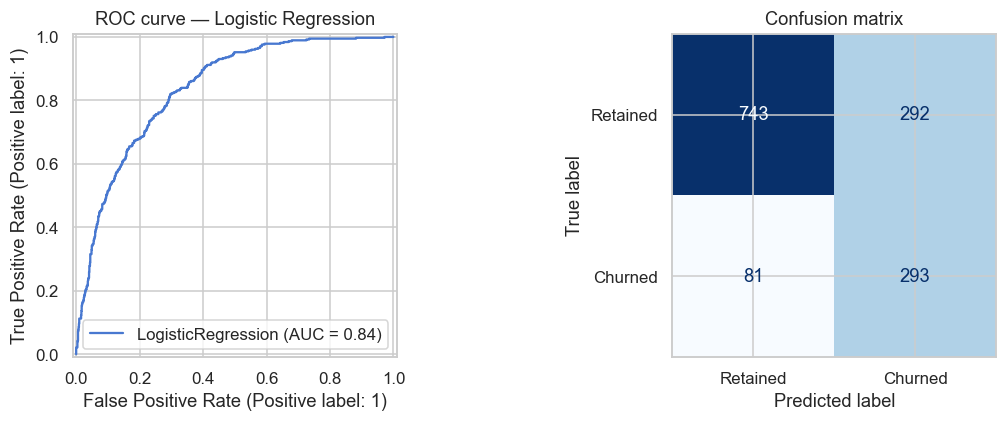

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

RocCurveDisplay.from_estimator(lr, X_test_s, y_test, ax=ax1)
ax1.set_title('ROC curve — Logistic Regression')

ConfusionMatrixDisplay.from_estimator(lr, X_test_s, y_test, ax=ax2,
                                       display_labels=['Retained', 'Churned'],
                                       cmap='Blues', colorbar=False)
ax2.set_title('Confusion matrix')
plt.tight_layout()
plt.show()

### 5 · Feature importance (logistic regression coefficients)

The magnitude of each coefficient tells us how strongly the model weights each feature.  
This should align with our EDA findings from NB2 — if not, investigate.

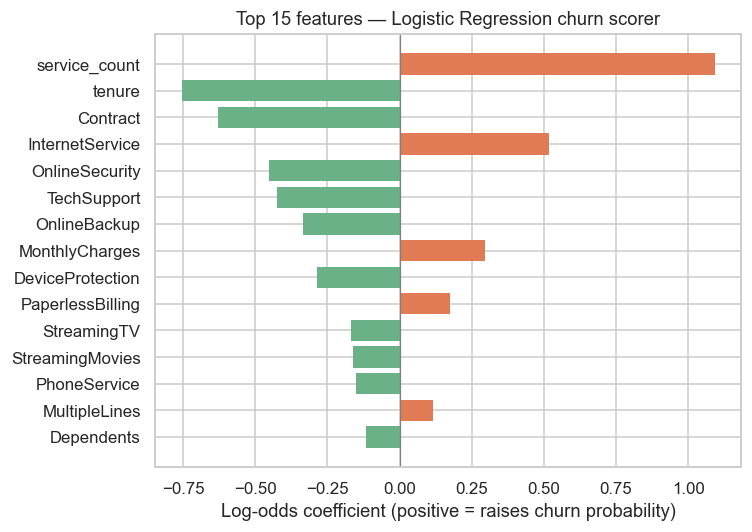

In [7]:
coef_df = pd.DataFrame({'feature': X.columns, 'coef': lr.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index)

top = coef_df.head(15)
colors = ['#e07b54' if c > 0 else '#6ab187' for c in top['coef']]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top['feature'][::-1], top['coef'][::-1], color=colors[::-1], edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Log-odds coefficient (positive = raises churn probability)')
ax.set_title('Top 15 features — Logistic Regression churn scorer')
plt.tight_layout()
plt.show()

### 6 · Gradient boosting upgrade

A gradient boosted model typically improves AUC by 2–4 points over logistic regression on this dataset.  
We compare them side-by-side and extract feature importances.

In [8]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                 max_depth=4, random_state=42)
gb.fit(X_train, y_train)  # GBM handles raw features well without scaling

gb_proba = gb.predict_proba(X_test)[:, 1]
print(f'Logistic Regression  AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'Gradient Boosting    AUC: {roc_auc_score(y_test, gb_proba):.4f}')

Logistic Regression  AUC: 0.8367
Gradient Boosting    AUC: 0.8422


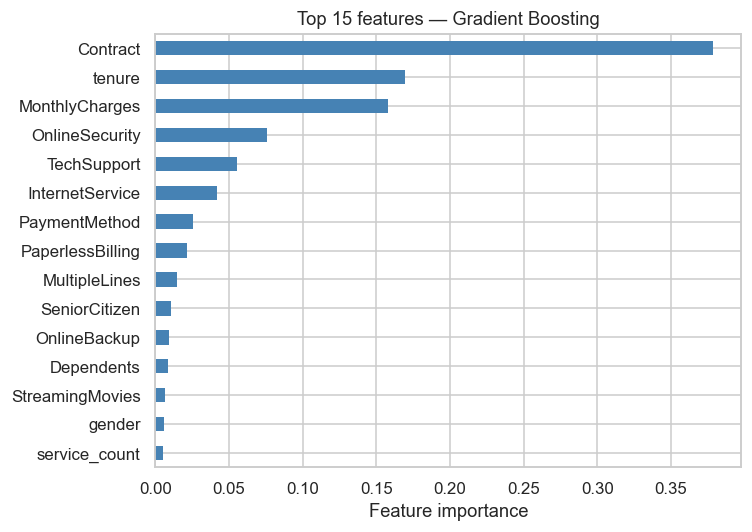

In [9]:
# GBM feature importance
fi = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7, 5))
fi[::-1].plot.barh(ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Top 15 features — Gradient Boosting')
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()

### 7 · Score entire customer base & export priority list

Apply the GBM model to the full dataset.  
Export a CSV of the top 200 at-risk, high-value customers — ready for a CRM campaign.

In [10]:
df_scored = pd.read_csv('telco_segmented.csv')

ml_full = df_scored.drop(columns=['customerID', 'TotalCharges', 'Churn', 'pca_1', 'pca_2',
                                    'charge_bin', 'tenure_bin', 'cluster', 'risk_score',
                                    'Churn_flag'], errors='ignore')
for col in ml_full.select_dtypes('object').columns:
    le = LabelEncoder()
    ml_full[col] = le.fit_transform(ml_full[col].astype(str))
bin_cols2 = [c for c in ml_full.columns if c.endswith('_bin')]
ml_full = ml_full.drop(columns=bin_cols2, errors='ignore')

# Align columns to training set
ml_full = ml_full[X.columns]

df_scored['churn_probability'] = gb.predict_proba(ml_full)[:, 1]

# Priority list: active customers (not already churned), sorted by (churn_prob × monthly_charges)
active = df_scored[df_scored['Churn_flag'] == 0].copy()
active['priority_score'] = active['churn_probability'] * active['MonthlyCharges']
top200 = active.nlargest(200, 'priority_score')[[
    'customerID', 'segment', 'tenure', 'MonthlyCharges',
    'Contract', 'churn_probability', 'priority_score'
]].round(3)

top200.to_csv('retention_targets.csv', index=False)
print('Saved retention_targets.csv')
print(top200.head(10).to_string(index=False))

Saved retention_targets.csv
customerID          segment  tenure  MonthlyCharges       Contract  churn_probability  priority_score
3292-PBZEJ New & vulnerable      11          111.40 Month-to-month              0.791          88.168
2754-SDJRD New & vulnerable       8          100.15 Month-to-month              0.878          87.972
4445-ZJNMU New & vulnerable       9           99.30 Month-to-month              0.848          84.182
4132-KALRO New & vulnerable       4          100.85 Month-to-month              0.830          83.708
5150-ITWWB New & vulnerable       3           94.85 Month-to-month              0.853          80.894
8161-QYMTT New & vulnerable       7           94.10 Month-to-month              0.854          80.316
4927-WWOOZ New & vulnerable       2           91.45 Month-to-month              0.873          79.858
6215-NQCPY  Established M2M      15           99.70 Month-to-month              0.762          75.949
6969-MVBAI New & vulnerable       9           90.10 Mo